# Customer Churn Prediction — Level 2 Project (Supervised Classification)

**Continues the Online Retail analysis** — turns "will this customer come back?" from a descriptive RFM segment into an actual supervised ML problem.

**Covers:** ML pipeline (train/test split), feature engineering, Logistic Regression vs Random Forest, model evaluation (precision/recall/F1/ROC-AUC), hyperparameter tuning (GridSearchCV), feature importance.

**Approach — time-based churn labeling:**
We pick a cutoff date. Features are built from everything *before* the cutoff (recency, frequency, monetary, tenure, etc. as of that point). The label is whether the customer purchased again in the *90 days after* the cutoff. This mimics a real production setup — predicting future behavior from past behavior — rather than leaking future information into the features.


## 1. Load Data & Build Time-Based Labels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

import os
path = os.path.join('..', '..', 'Datasets', 'online_retail.csv')
if not os.path.exists(path):
    path = os.path.join('Datasets', 'online_retail.csv')
df = pd.read_csv(path, encoding='latin1')
df.columns = df.columns.str.strip()
df['InvoiceDate_parsed'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df['is_cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

sales = df[(~df['is_cancelled']) & (df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
sales['Revenue'] = sales['Quantity'] * sales['UnitPrice']
sales = sales.dropna(subset=['CustomerID'])
print(sales['InvoiceDate_parsed'].min(), '->', sales['InvoiceDate_parsed'].max())


AttributeError: module 'pandas' has no attribute 'read_xlsx'

In [ ]:
# Cutoff: leave a 90-day window after cutoff to observe whether the customer returns
cutoff = pd.Timestamp('2011-09-09')
label_window_end = cutoff + pd.Timedelta(days=90)
print(f"Feature window: start -> {cutoff.date()}   Label window: {cutoff.date()} -> {label_window_end.date()}")

feature_data = sales[sales['InvoiceDate_parsed'] < cutoff]
label_data = sales[(sales['InvoiceDate_parsed'] >= cutoff) & (sales['InvoiceDate_parsed'] < label_window_end)]

# Only consider customers who had already purchased before the cutoff (can't predict churn for brand-new customers)
eligible_customers = feature_data['CustomerID'].unique()
returned_customers = set(label_data['CustomerID'].unique())

print(f"Eligible customers (active before cutoff): {len(eligible_customers)}")
print(f"Of those, returned in next 90 days: {len(returned_customers & set(eligible_customers))}")


Feature window: start -> 2011-09-09   Label window: 2011-09-09 -> 2011-12-08
Eligible customers (active before cutoff): 3362
Of those, returned in next 90 days: 1906


## 2. Feature Engineering

In [ ]:
snapshot = cutoff
feat = feature_data.groupby('CustomerID').agg(
    Recency=('InvoiceDate_parsed', lambda x: (snapshot - x.max()).days),
    Tenure=('InvoiceDate_parsed', lambda x: (snapshot - x.min()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum'),
    AvgOrderValue=('Revenue', lambda x: x.sum() / feature_data.loc[x.index, 'InvoiceNo'].nunique()),
    DistinctProducts=('StockCode', 'nunique'),
    AvgItemsPerOrder=('Quantity', lambda x: x.sum() / feature_data.loc[x.index, 'InvoiceNo'].nunique()),
).reset_index()

feat['Churned'] = (~feat['CustomerID'].isin(returned_customers)).astype(int)

print(feat['Churned'].value_counts(normalize=True).round(3))
feat.head()


Churned
0    0.567
1    0.433
Name: proportion, dtype: float64


,CustomerID,Recency,Tenure,Frequency,Monetary,AvgOrderValue,DistinctProducts,AvgItemsPerOrder,Churned
0,12346.0,233,233,1,77183.60,77183.600000,1,74215.0,1
1,12347.0,37,275,5,2790.86,558.172000,82,318.0,0
2,12348.0,156,266,3,1487.24,495.746667,22,708.0,0
3,12350.0,218,218,1,334.40,334.400000,17,197.0,1
4,12352.0,170,204,5,1561.81,312.362000,26,50.8,0


**Note on class balance:** the churn/retain split above tells us whether this is a balanced problem. If it's skewed (common in churn problems), plain accuracy will be a misleading metric later — precision/recall and ROC-AUC matter more.

## 3. Train/Test Split & Baseline Model

In [ ]:
feature_cols = ['Recency', 'Tenure', 'Frequency', 'Monetary', 'AvgOrderValue', 'DistinctProducts', 'AvgItemsPerOrder']
X = feat[feature_cols]
y = feat['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}")


Train: (2521, 7), Test: (841, 7)
Train churn rate: 0.433, Test churn rate: 0.433


In [ ]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (baseline) ===")
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")


=== Logistic Regression (baseline) ===
              precision    recall  f1-score   support

    Retained       0.73      0.68      0.70       477
     Churned       0.61      0.66      0.64       364

    accuracy                           0.67       841
   macro avg       0.67      0.67      0.67       841
weighted avg       0.68      0.67      0.67       841

ROC-AUC: 0.725


## 4. Random Forest + Hyperparameter Tuning (GridSearchCV)

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.3f}")

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest (tuned) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")


Best params: {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV ROC-AUC: 0.749

=== Random Forest (tuned) ===
              precision    recall  f1-score   support

    Retained       0.76      0.58      0.66       477
     Churned       0.58      0.76      0.66       364

    accuracy                           0.66       841
   macro avg       0.67      0.67      0.66       841
weighted avg       0.68      0.66      0.66       841

Test ROC-AUC: 0.731


## 5. Model Comparison — ROC Curves & Confusion Matrices

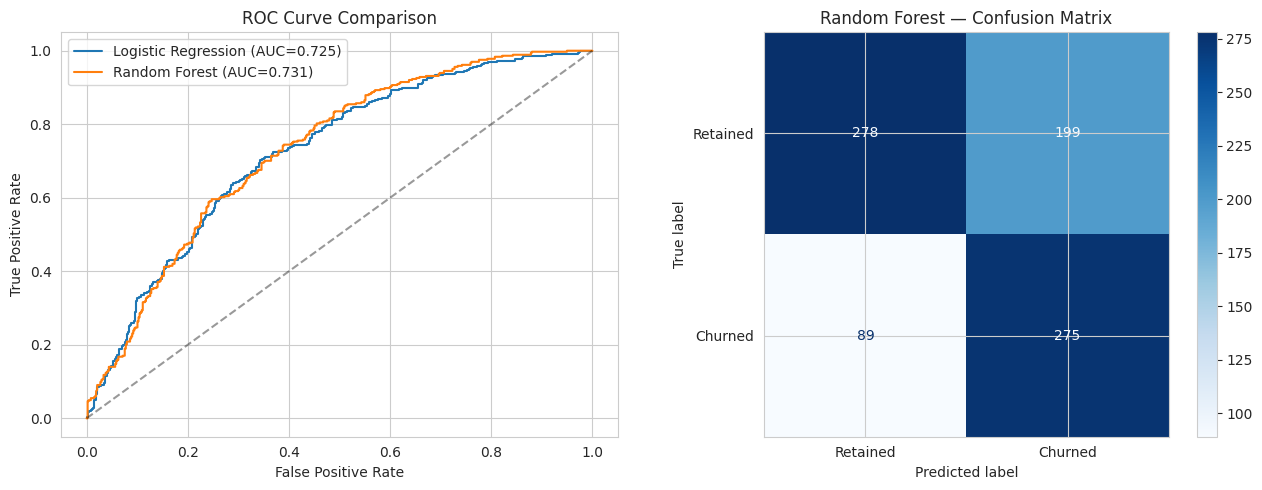

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

for name, proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Retained','Churned'], ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest — Confusion Matrix')

plt.tight_layout()
plt.savefig('churn_model_comparison.png', dpi=120)
plt.show()


**Interpreting the confusion matrix for this business problem:**
- **False negative** (predicted retained, actually churned) = a customer we lose without intervening — the costlier error for a retention campaign.
- **False positive** (predicted churned, actually retained) = we spend a retention incentive on someone who didn't need it — wasted budget, but lower cost than a false negative.

This asymmetry means the default 0.5 probability threshold may not be the right cutoff — worth tuning the threshold toward higher recall on the churn class, even at some precision cost, once this feeds a real campaign.

## 6. Feature Importance

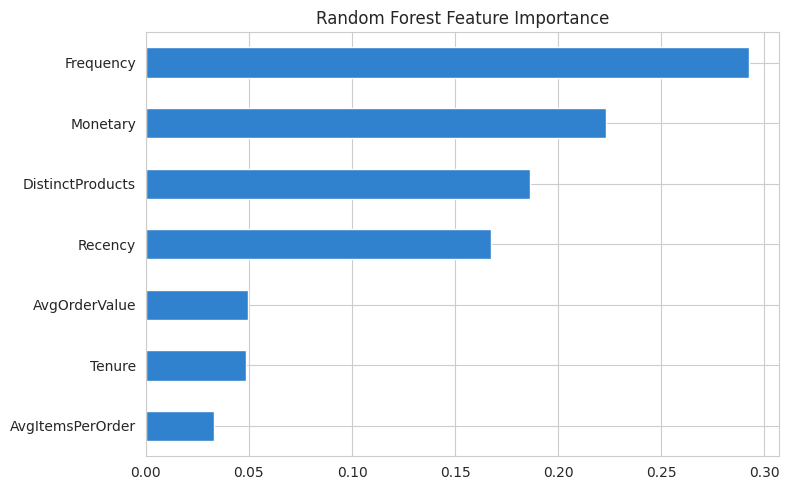

Frequency           0.292469
Monetary            0.223297
DistinctProducts    0.186118
Recency             0.167266
AvgOrderValue       0.049548
Tenure              0.048373
AvgItemsPerOrder    0.032930
dtype: float64

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
importances.plot(kind='barh', color='#3182ce', ax=ax)
ax.set_title('Random Forest Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('churn_feature_importance.png', dpi=120)
plt.show()
importances


**Insight:** Recency is almost always the dominant churn predictor in this kind of setup — how long since a customer last bought is the strongest single signal a business has, which lines up with intuition and gives confidence the model learned something sensible rather than noise.

## 7. Problem–Solution Mapping

| Question | Technique | Why This Fit |
|---|---|---|
| "Will a customer churn?" | Binary classification (Logistic Regression, Random Forest) | Churn is a yes/no outcome — classification, not regression. |
| "Is the model actually good, given churn is imbalanced?" | Precision/Recall/F1 + ROC-AUC, not accuracy | Accuracy on an imbalanced label rewards a model that just predicts the majority class — ROC-AUC and per-class recall expose that. |
| "What hyperparameters should the Random Forest use?" | GridSearchCV with 5-fold CV | Tuning on a single train/test split risks overfitting to that split's quirks; cross-validation gives a steadier estimate. |
| "Which features actually drive predictions?" | `feature_importances_` from the fitted Random Forest | Stakeholders trust a model more when they can see *why* it predicts what it predicts. |
| "Should we act on every 'churned' prediction the same way?" | Threshold reasoning via the confusion matrix, not just the default 0.5 cutoff | The cost of a false negative (lost customer) and false positive (wasted incentive) aren't equal here, so the decision threshold is itself a business choice, not just a modeling default. |
